In [13]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- ETAPE A : CHARGEMENT ---
try:
    # On utilise latin1 pour éviter les erreurs sur les accents tunisiens
    df_res = pd.read_csv('Fact_reservation.csv', encoding='latin1')
    df_events = pd.read_csv('dim_events.csv', encoding='latin1', on_bad_lines='skip')
    df_service = pd.read_csv('dim_service.csv', encoding='latin1')
    df_eval = pd.read_csv('dim_eval.csv', encoding='latin1')

    # --- ETAPE B : FUSION (MERGE) ---
    data = df_res.merge(df_events, on='id_event', how='left')
    data = data.merge(df_service, on='id_service', how='left')
    data = data.merge(df_eval, on='id_evaluation', how='left')

    # --- ETAPE C : PREPARATION ML ---
    # Cible : 1 si annulé (statut 3), 0 sinon
    data['is_canceled'] = data['id_status'].apply(lambda x: 1 if x == 3 else 0)

    # Encodage du texte en chiffres
    le = LabelEncoder()
    data['rating_num'] = le.fit_transform(data['rating'].astype(str))

    # Sélection des colonnes pour l'IA
    features = ['id_event', 'id_service', 'rating_num', 'final_price']
    X = data[features].fillna(0)
    y = data['is_canceled']

    # --- ETAPE D : ENTRAÎNEMENT ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X_train, y_train)

    print(f" SUCCÈS ! Modèle prêt avec une précision de : {model.score(X_test, y_test):.2%}")

except FileNotFoundError as e:
    print(f" ERREUR : Le fichier {e.filename} est introuvable. Vérifie l'upload à gauche !")
except Exception as e:
    print(f"Autre erreur : {e}")

 SUCCÈS ! Modèle prêt avec une précision de : 63.72%


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Créer et entraîner le 2ème modèle
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

# 2. Comparaison des scores
score_rf = model.score(X_test, y_test)
score_log = model_log.score(X_test, y_test)

print(f"Précision Random Forest : {score_rf:.2%}")
print(f"Précision Régression Logistique : {score_log:.2%}")


Précision Random Forest : 63.13%
Précision Régression Logistique : 66.81%


--- Résultats de l'Optimisation (GridSearch) ---
      Hyperparamètre  Meilleure Valeur
0          max_depth                10
1  min_samples_split                 5
2       n_estimators                50
 Score moyen Cross-Validation: 65.58%

 RAPPORT DE CLASSIFICATION (RANDOM FOREST) :
              precision    recall  f1-score   support

           0       0.67      0.99      0.80       908
           1       0.27      0.01      0.01       451

    accuracy                           0.66      1359
   macro avg       0.47      0.50      0.41      1359
weighted avg       0.54      0.66      0.54      1359



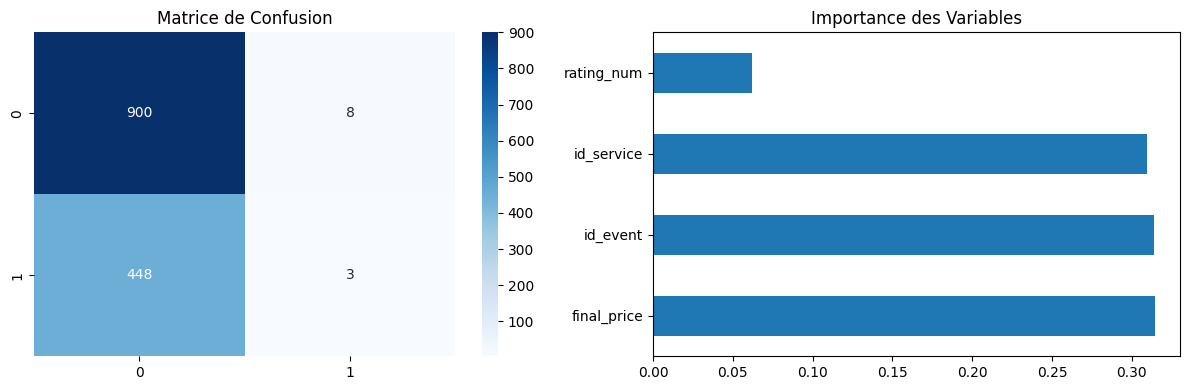

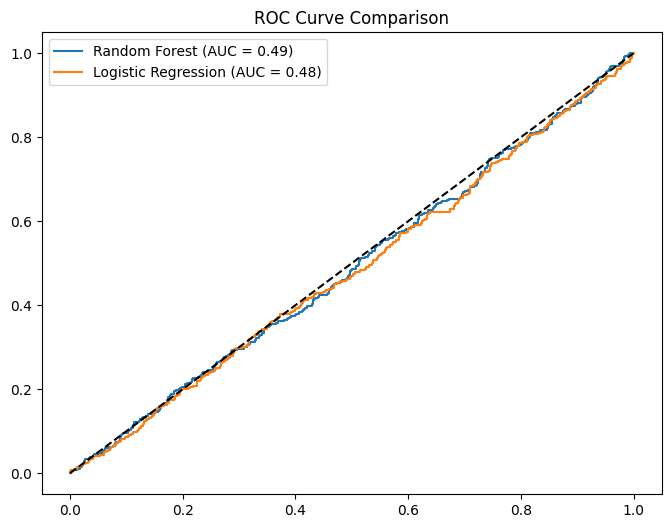

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. PIPELINE & TUNING (Point 1 du document) ---
# On définit les paramètres à tester pour le Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# Recherche du meilleur modèle avec GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# Extraire les meilleurs paramètres trouvés par GridSearch
params = grid_search.best_params_

# Créer un DataFrame pour un affichage propre
df_params = pd.DataFrame(list(params.items()), columns=['Hyperparamètre', 'Meilleure Valeur'])

print("--- Résultats de l'Optimisation (GridSearch) ---")
print(df_params)

# --- 2. DEUXIÈME MODÈLE & CROSS-VALIDATION (Point 2) ---
model_log = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)

print(f" Score moyen Cross-Validation: {cv_scores.mean():.2%}")

# --- 3. COMPARAISON DES MÉTRIQUES (Point 3) ---
y_pred_rf = best_rf.predict(X_test)
print("\n RAPPORT DE CLASSIFICATION (RANDOM FOREST) :")
print(classification_report(y_test, y_pred_rf))

# --- 4. VISUALISATIONS (Point 4 & 5) ---

# A. Matrice de Confusion
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')

# B. Feature Importance (Importance des variables)
plt.subplot(1, 2, 2)
importances = pd.Series(best_rf.feature_importances_, index=features)
importances.nlargest(4).plot(kind='barh')
plt.title('Importance des Variables')
plt.tight_layout()
plt.show()

# C. Courbe ROC (Comparaison finale)
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:,1])
fpr_log, tpr_log, _ = roc_curve(y_test, model_log.fit(X_train, y_train).predict_proba(X_test)[:,1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()